### Importing Necessary Libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('HospInfo.csv')

### Data Understanding

In [5]:
def data_understanding(df):
        print(f"{'*' * 50} Data Information {'*' * 68}")
        display(df.info())
        print(f"\n{'*' * 50} Checking For Duplicate Values {'*' * 55}")
        display(df.duplicated().sum())
        print(f"\n{'*' * 50} Description of Numerical Columns {'*' * 52}")
        display(df.describe())
        print(f"\n{'*' * 50} Description of Categorical Columns {'*' * 50}")
        display(df.describe(include = 'object'))
        print(f"\n{'*' * 50} DataFrame Summary {'*' * 50}")
        display(df.head())
    
data_understanding(df)

************************************************** Data Information ********************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4812 entries, 0 to 4811
Data columns (total 29 columns):
 #   Column                                                         Non-Null Count  Dtype 
---  ------                                                         --------------  ----- 
 0   Provider ID                                                    4812 non-null   int64 
 1   Hospital Name                                                  4812 non-null   object
 2   Address                                                        4812 non-null   object
 3   City                                                           4812 non-null   object
 4   State                                                          4812 non-null   object
 5   ZIP Code                                                       4812 non-null   int64 
 6   County Name            

None


************************************************** Checking For Duplicate Values *******************************************************


0


************************************************** Description of Numerical Columns ****************************************************


,Provider ID,ZIP Code,Phone Number
count,4812.000000,4812.000000,4.812000e+03
mean,268294.422901,53990.132377,5.848244e+09
std,157109.340215,26915.916870,2.332196e+09
min,10001.000000,603.000000,9.369338e+08
25%,140185.750000,33015.250000,4.014563e+09
50%,260043.500000,55410.500000,6.053360e+09
75%,390222.250000,76035.500000,7.877574e+09
max,670118.000000,99929.000000,9.898943e+09



************************************************** Description of Categorical Columns **************************************************


,Hospital Name,Address,City,State,County Name,Hospital Type,Hospital Ownership,Meets criteria for meaningful use of EHRs,Hospital overall rating,Hospital overall rating footnote,...,Readmission national comparison footnote,Patient experience national comparison,Patient experience national comparison footnote,Effectiveness of care national comparison,Effectiveness of care national comparison footnote,Timeliness of care national comparison,Timeliness of care national comparison footnote,Efficient use of medical imaging national comparison,Efficient use of medical imaging national comparison footnote,Location
count,4812,4812,4812,4812,4797,4812,4812,4668,4812,1398,...,1017,4812,1369,4812,1202,4812,1266,4812,2033,4812
unique,4623,4784,2947,56,1563,3,10,1,6,5,...,3,4,3,4,3,4,3,4,3,4810
top,MEMORIAL HOSPITAL,100 HOSPITAL DRIVE,CHICAGO,TX,LOS ANGELES,Acute Care Hospitals,Voluntary non-profit - Private,True,3,There are too few measures or measure groups r...,...,Results are not available for this reporting p...,Not Available,Results are not available for this reporting p...,Same as the national average,Results are not available for this reporting p...,Same as the national average,Results are not available for this reporting p...,Same as the national average,Results are not available for this reporting p...,"105 WALL STREET\nPOTEAU, OK\n(35.043979, -94.6..."
freq,15,7,29,411,83,3369,2052,4668,1761,995,...,809,1369,1161,3238,994,1554,1058,2051,1825,2



************************************************** DataFrame Summary **************************************************


,Provider ID,Hospital Name,Address,City,State,ZIP Code,County Name,Phone Number,Hospital Type,Hospital Ownership,...,Readmission national comparison footnote,Patient experience national comparison,Patient experience national comparison footnote,Effectiveness of care national comparison,Effectiveness of care national comparison footnote,Timeliness of care national comparison,Timeliness of care national comparison footnote,Efficient use of medical imaging national comparison,Efficient use of medical imaging national comparison footnote,Location
0,10005,MARSHALL MEDICAL CENTER SOUTH,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,2565938310,Acute Care Hospitals,Government - Hospital District or Authority,...,NaN,Same as the national average,NaN,Same as the national average,NaN,Above the national average,NaN,Below the national average,NaN,"2505 U S HIGHWAY 431 NORTH\nBOAZ, AL\n"
1,10012,DEKALB REGIONAL MEDICAL CENTER,200 MED CENTER DRIVE,FORT PAYNE,AL,35968,DE KALB,2568453150,Acute Care Hospitals,Proprietary,...,NaN,Same as the national average,NaN,Same as the national average,NaN,Above the national average,NaN,Same as the national average,NaN,"200 MED CENTER DRIVE\nFORT PAYNE, AL\n"
2,10032,WEDOWEE HOSPITAL,209 NORTH MAIN STREET,WEDOWEE,AL,36278,RANDOLPH,2563572111,Acute Care Hospitals,Government - Hospital District or Authority,...,NaN,Not Available,Results are not available for this reporting p...,Same as the national average,NaN,Same as the national average,NaN,Not Available,Results are not available for this reporting p...,"209 NORTH MAIN STREET\nWEDOWEE, AL\n"
3,10095,HALE COUNTY HOSPITAL,508 GREEN STREET,GREENSBORO,AL,36744,HALE,3346243024,Acute Care Hospitals,Government - Local,...,Results are not available for this reporting p...,Not Available,Results are not available for this reporting p...,Below the national average,NaN,Same as the national average,NaN,Not Available,Results are not available for this reporting p...,"508 GREEN STREET\nGREENSBORO, AL\n"
4,10131,CRESTWOOD MEDICAL CENTER,ONE HOSPITAL DR SE,HUNTSVILLE,AL,35801,MADISON,2568823100,Acute Care Hospitals,Proprietary,...,NaN,Same as the national average,NaN,Same as the national average,NaN,Same as the national average,NaN,Same as the national average,NaN,"ONE HOSPITAL DR SE\nHUNTSVILLE, AL\n"


### Data Cleaning

In [7]:
# Function to clean the data
def cleaned_data(df):
    # Rename Columns 
    df = df.rename(columns = {'Hospital Name': 'hospital_name','State': 'state','Hospital Type': 'hospital_type','Hospital Ownership': 'ownership',
                              'Emergency Services': 'emergency','Hospital overall rating': 'rating','Mortality national comparison': 'mortality',
                              'Readmission national comparison': 'readmission','Patient experience national comparison': 'patient_experience',
                              'Effectiveness of care national comparison': 'effectiveness',
                              'Timeliness of care national comparison': 'timeliness','Safety of care national comparison': 'safety',
                              'Efficient use of medical imaging national comparison': 'imaging_efficiency','Meets criteria for meaningful use of EHRs': 'ehr_use'})

    # Convert hospital performance categories to numeric scores for easier analysis
    score_map = {
        'Above the national average': 3,
        'Same as the national average': 2,
        'Below the national average': 1,
        'Not Available': 0
    }
    
    cols = ['mortality', 'readmission', 'patient_experience', 'effectiveness', 'timeliness', 'safety']
    
    for col in cols:
        df[col] = df[col].map(score_map)

    df['avg_perf_score'] = df[cols].mean(axis=1).round(2)


    # Function to assign letter grades to hospitals based on their average performance score
    def hospital_grades(row):
        if row['avg_perf_score'] >= 2.5:
            return 'A'
        elif row['avg_perf_score'] >= 2.0:
            return 'B'
        elif row['avg_perf_score'] >= 1.0:
            return 'C'
        else:
            return 'D'

    df['grade'] = df.apply(hospital_grades, axis=1)
    df = df
    return df

df = cleaned_data(df)

### Exploratory Data Analysis

In [23]:
def visualizations(df):
    # Set visual theme
    sns.set_theme(style="whitegrid", palette="pastel")
    colors = ['#C5DCA0', '#F7B7A3', '#BFD7EA', '#E2C2B9']
    
    # Distribution of Hospital Grades
    df['grade'].value_counts().plot(
        kind='pie',
        autopct='%.2f%%',
        colors=colors,
        title='Distribution of Hospital Grades')
    plt.ylabel('')
    plt.show()

    # Hospital Count by Type
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(x='hospital_type', data=df, palette='pastel')
    ax.bar_label(ax.containers[0])
    plt.title('Hospital Count by Type')
    plt.xticks(rotation=20)
    plt.show()

    # Hospital Count by Ownership
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(y='ownership', data=df, palette='pastel')
    ax.bar_label(ax.containers[0])
    plt.title('Hospital Count by Ownership')
    plt.show()

    # Emergency Services Availability
    df['emergency'].value_counts().plot.pie(
        labels=['Yes', 'No'],
        autopct='%.2f%%',
        colors=['#C5DCA0', '#F7B7A3']
    )
    plt.title('Emergency Services Availability')
    plt.ylabel('')
    plt.show()

    # Average Performance Score by Top 10 States
    plt.figure(figsize=(10, 6))
    top_states = df.groupby('state')['avg_perf_score'].mean().sort_values(ascending=False).head(10)
    ax = sns.barplot(x=top_states.index, y=top_states.values, palette='pastel')
    ax.bar_label(ax.containers[0])
    plt.ylabel('Average Performance Score')
    plt.title('Top 10 States by Avg Hospital Performance')
    plt.show()

    # Correlation Heatmap
    plt.figure(figsize=(8, 6))
    score_cols = ['mortality', 'readmission', 'patient_experience', 'effectiveness', 'timeliness', 'safety', 'avg_perf_score']
    sns.heatmap(df[score_cols].corr(), annot=True, cmap='YlGnBu')
    plt.title('Correlation Between Performance Metrics')
    plt.show

    # Grade Distribution by Hospital Type
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(x='hospital_type', hue='grade', data=df, palette='pastel')
    plt.title('Grade Distribution by Hospital Type')
    plt.xticks(rotation=20)
    plt.legend(title='Grade')
    plt.show()

    # Average Score by Emergency Availability
    emergency_avg = df.groupby('emergency')['avg_perf_score'].mean().reset_index()
    ax = sns.barplot(x='emergency', y='avg_perf_score', data=emergency_avg, palette=['#C5DCA0', '#F7B7A3'])
    ax.bar_label(ax.containers[0])
    plt.title('Average Performance by Emergency Services')
    plt.xlabel('Emergency Services')
    plt.ylabel('Avg Performance Score')
    plt.show()

    # Rating vs Avg Performance Boxplot
    plt.figure(figsize=(10, 6))
    ax = sns.boxplot(x='rating', y='avg_perf_score', data=df, palette='pastel')
    plt.title('Avg Performance Score Across Hospital Ratings')
    plt.xlabel('Hospital Rating')
    plt.ylabel('Avg Performance Score')
    plt.show()


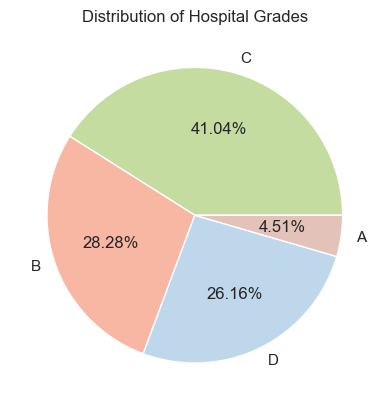

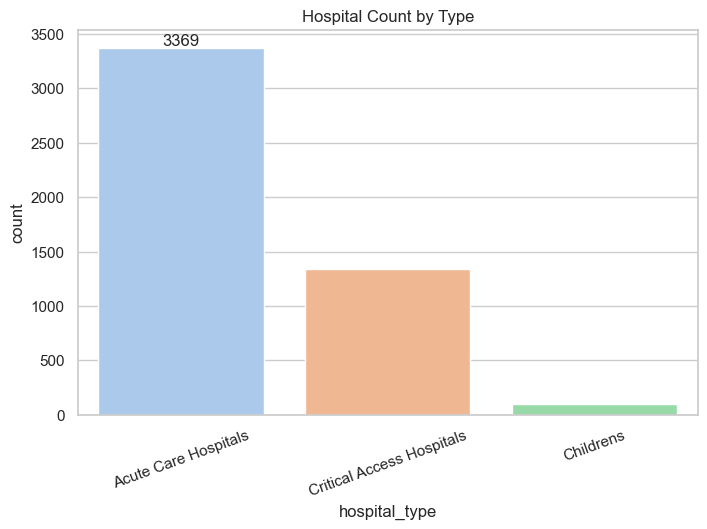

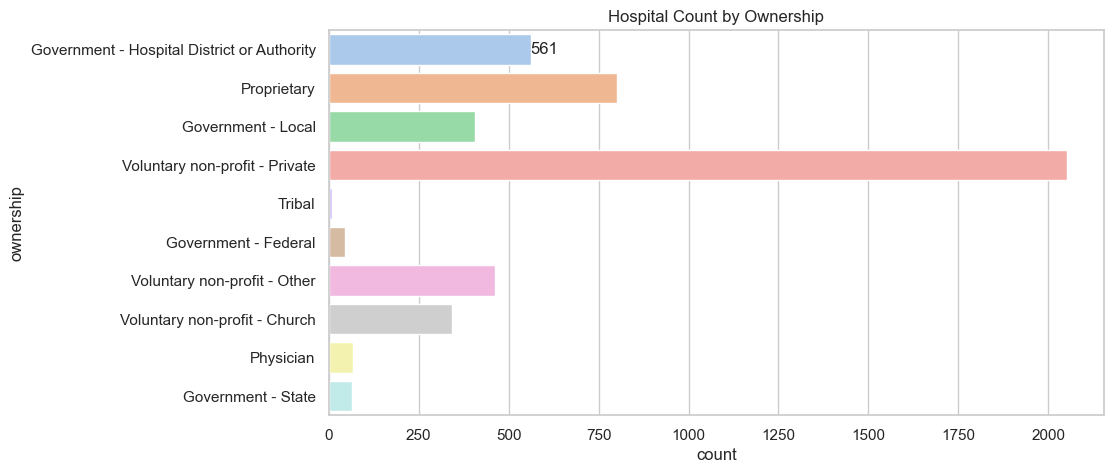

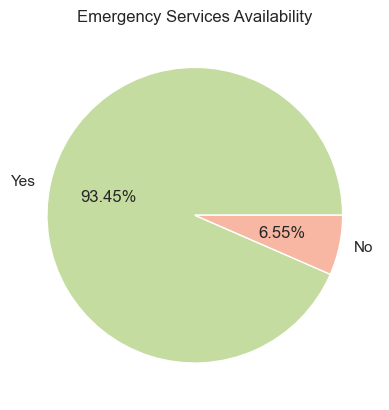

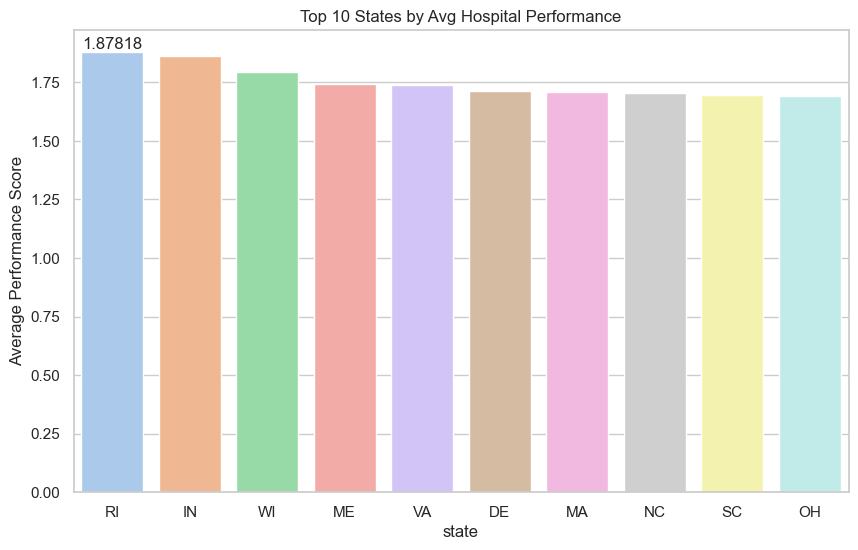

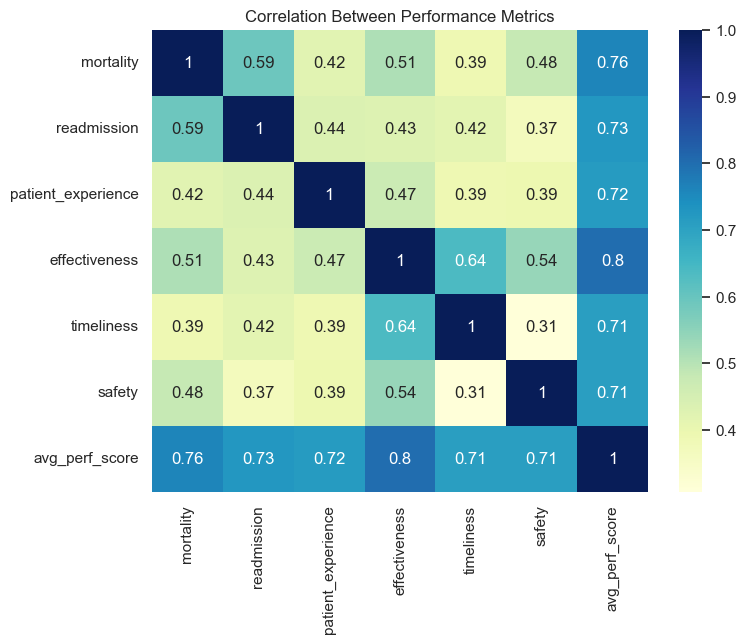

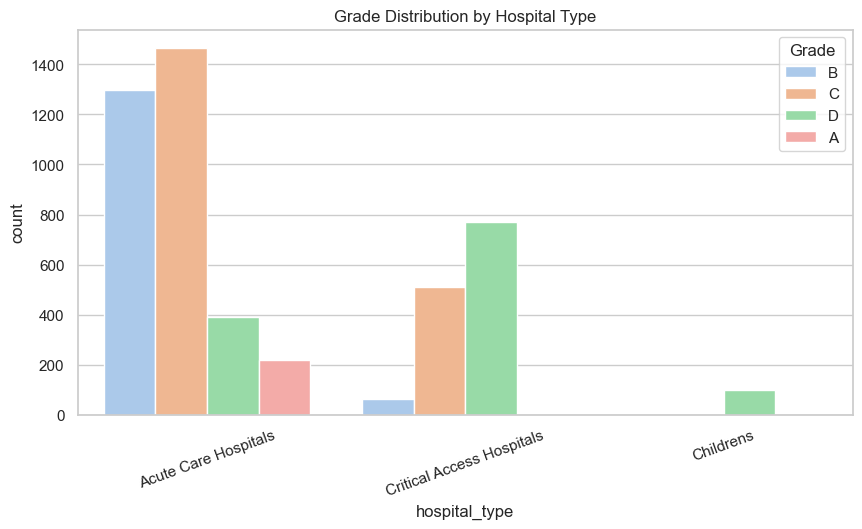

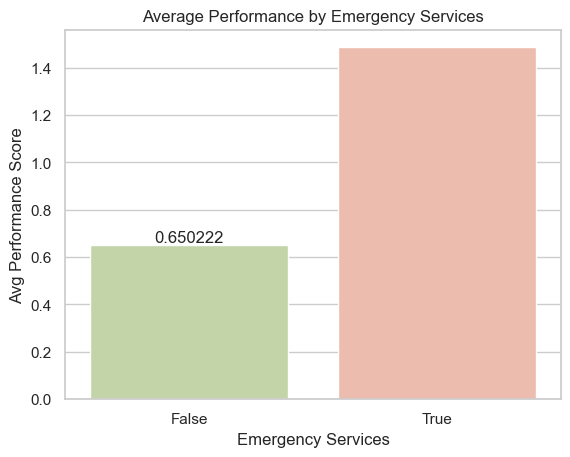

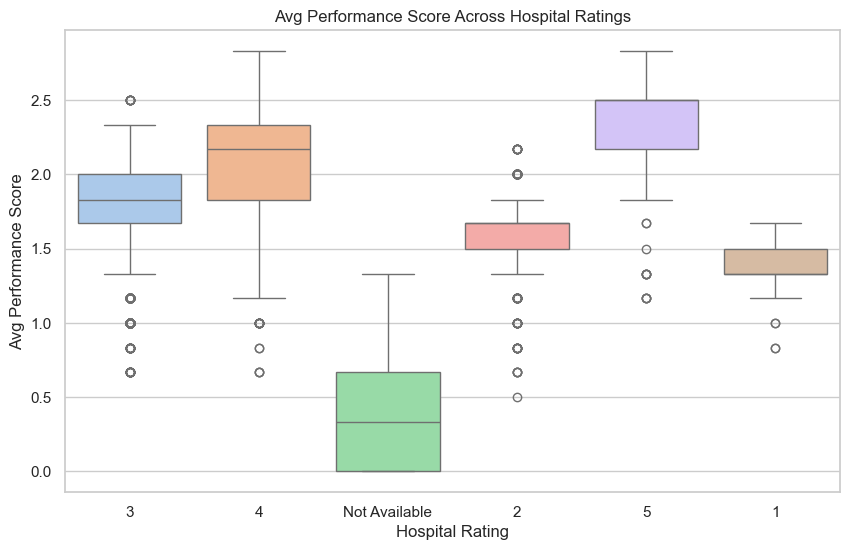

In [25]:
visualizations(df)

### Insights and Suggestions

In [28]:
def insights_suggestions():
    print(f"{'*' * 50} Insights {'*' * 50}")

    print(
        '''
    1. Grade Distribution
        - Most hospitals fall under Grade B and C categories.
        - Very few hospitals achieved Grade A performance.

    2. Hospital Type Influence
        - General acute care hospitals are the most common and show a wide range in performance.
        - Specialty hospitals tend to perform better on average.

    3. Ownership Patterns
        - Government-owned hospitals generally score lower than private or nonprofit hospitals.
        - Private hospitals show more consistency in high scores.

    4. Emergency Services Impact
        - Hospitals with emergency services tend to have slightly higher average performance scores.
        - Suggests better readiness and operational standards.

    5. State-Level Variations
        - Some states consistently have hospitals with higher avg performance.
        - Indicates regional disparities in healthcare quality.

    6. Metric Correlation
        - Strong positive correlation between mortality, readmission, and overall performance.
        - Suggests improving one metric may positively influence others.
        '''
    )

    print(f"{'*' * 50} Suggestions {'*' * 50}")

    print(
        '''
    1. Focus on Mid-Performing Hospitals
        - Grades B and C dominate the distribution.
        - Provide targeted support to push them to Grade A.

    2. Support for Government Hospitals
        - These tend to underperform.
        - Increase funding, staff training, and infrastructure improvements.

    3. Leverage Emergency Capabilities
        - Emergency-enabled hospitals perform better.
        - Expand emergency care readiness across hospitals.

    4. Regional Improvement Plans
        - Identify low-performing states and create improvement programs.
        - Benchmark them against top-performing regions.

    5. Improve Patient Experience
        - Patient experience is a key factor in overall scores.
        - Train staff and improve facilities to boost satisfaction.

    6. Integrated Metric Approach
        - Improve mortality and readmission rates simultaneously.
        - These metrics are interrelated and boost overall performance.
        '''
    )

In [30]:
insights_suggestions()

************************************************** Insights **************************************************

    1. Grade Distribution
        - Most hospitals fall under Grade B and C categories.
        - Very few hospitals achieved Grade A performance.

    2. Hospital Type Influence
        - General acute care hospitals are the most common and show a wide range in performance.
        - Specialty hospitals tend to perform better on average.

    3. Ownership Patterns
        - Government-owned hospitals generally score lower than private or nonprofit hospitals.
        - Private hospitals show more consistency in high scores.

    4. Emergency Services Impact
        - Hospitals with emergency services tend to have slightly higher average performance scores.
        - Suggests better readiness and operational standards.

    5. State-Level Variations
        - Some states consistently have hospitals with higher avg performance.
        - Indicates regional disparities in health

In [34]:
df.to_csv('HospInfo.csv')